In [2]:
import rich
import logging
import glob
import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
import json 
import yaml

import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# functions


In [3]:


def estimate_active_time(df, max_gap=60):
    timestamps = np.sort(
        df["timestamp"].dropna().to_numpy()
    )

    dt = np.diff(timestamps)

    # Somma soltanto gli intervalli inferiori alla soglia
    return dt[dt <= max_gap].sum()

def subtract_background(
    energy_data,
    energy_background,
    bin_edges,
    alpha
):
    counts_data, _ = np.histogram(
        energy_data,
        bins=bin_edges
    )

    counts_background, _ = np.histogram(
        energy_background,
        bins=bin_edges
    )

    counts_background_scaled = alpha * counts_background

    counts_net = (
        counts_data
        - counts_background_scaled
    )

    # Incertezza statistica sulla sottrazione
    errors_net = np.sqrt(
        counts_data
        + alpha**2 * counts_background
    )

    return {
        "data": counts_data,
        "background": counts_background,
        "background_scaled": counts_background_scaled,
        "net": counts_net,
        "error": errors_net
    }



def generic_polycone_profile(solid):
    r = np.asarray(
        solid.evaluateParameterWithUnits("pR"),
        dtype=float
    )
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZ"),
        dtype=float
    )

    return np.append(r, r[0]), np.append(z, z[0])


def polycone_profile(solid):
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZpl"),
        dtype=float
    )
    rmin = np.asarray(
        solid.evaluateParameterWithUnits("pRMin"),
        dtype=float
    )
    rmax = np.asarray(
        solid.evaluateParameterWithUnits("pRMax"),
        dtype=float
    )

    r = np.concatenate([rmax, rmin[::-1], [rmax[0]]])
    z = np.concatenate([z, z[::-1], [z[0]]])

    return r, z

    
def get_profile(solid):
    solid_type = str(solid.type).lower()

    if "genericpolycone" in solid_type:
        return generic_polycone_profile(solid)

    if "polycone" in solid_type:
        return polycone_profile(solid)

    if "tubs" in solid_type or "tube" in solid_type:
        return tubs_profile(solid)

    if "box" in solid_type:
        return box_profile(solid)

    raise TypeError(
        f"Solido {solid.name} di tipo {solid.type} non supportato"
    )

def evaluate_vector(vector):
    """Converte Position o Rotation di pyg4ometry in array numerico."""
    return np.asarray(vector.eval(), dtype=float)


def physical_volume_matrix(pv):
    """Matrice omogenea della trasformazione del PhysicalVolume."""
    position = evaluate_vector(pv.position)
    rotation = evaluate_vector(pv.rotation)

    rotation_matrix = np.linalg.inv(
        pg4.transformation.tbxyz2matrix(rotation)
    )

    matrix = np.eye(4)
    matrix[:3, :3] = rotation_matrix
    matrix[:3, 3] = position

    return matrix


def collect_global_placements(logical_volume, parent_matrix=None):
    """
    Percorre ricorsivamente il GDML e restituisce la trasformazione
    globale di ogni volume fisico.
    """
    if parent_matrix is None:
        parent_matrix = np.eye(4)

    placements = {}

    def walk(mother_lv, mother_matrix):
        for pv in mother_lv.daughterVolumes:
            local_matrix = physical_volume_matrix(pv)
            global_matrix = mother_matrix @ local_matrix

            logical_name = pv.logicalVolume.name

            placements.setdefault(logical_name, []).append({
                "physical_name": pv.name,
                "logical_volume": pv.logicalVolume,
                "matrix": global_matrix,
            })

            walk(pv.logicalVolume, global_matrix)

    walk(logical_volume, parent_matrix)

    return placements


def find_germanium_detector(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Germanium" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessun detector al germanio trovato")

    if len(candidates) > 1:
        print("Detector al germanio trovati:", candidates)

    return candidates[0]



def find_source(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Source" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessuna sorgente trovate")

    if len(candidates) > 1:
        print("Sorgente trovata:", candidates)

    return candidates[0]

def tubs_profile(solid):
    """Profilo r-z di un cilindro Tubs."""

    rmin = float(solid.evaluateParameterWithUnits("pRMin"))
    rmax = float(solid.evaluateParameterWithUnits("pRMax"))
    dz = float(solid.evaluateParameterWithUnits("pDz"))

    # pDz è la lunghezza totale lungo z
    zmin = -dz / 2
    zmax = dz / 2

    r = np.array([
        rmin,
        rmax,
        rmax,
        rmin,
        rmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def box_profile(solid):
    """Profilo nel piano locale x-z di un Box."""

    size_x = float(solid.evaluateParameterWithUnits("pX"))
    size_z = float(solid.evaluateParameterWithUnits("pZ"))

    xmin = -size_x / 2
    xmax = size_x / 2
    zmin = -size_z / 2
    zmax = size_z / 2

    r = np.array([
        xmin,
        xmax,
        xmax,
        xmin,
        xmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def transform_profile(r, z, matrix):
    """
    Trasforma un profilo locale (r, z) nelle coordinate globali.

    Parameters
    ----------
    r : array-like
        Coordinate radiali locali.
    z : array-like
        Coordinate verticali locali.
    matrix : array-like, shape (4, 4)
        Matrice omogenea contenente rotazione e traslazione globali.

    Returns
    -------
    radius : ndarray
        Distanza globale dall'asse z.
    height : ndarray
        Coordinata z globale.
    """

    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    # Punti omogenei locali: (x=r, y=0, z, 1)
    points = np.column_stack([
        r,
        np.zeros_like(r),
        z,
        np.ones_like(r)
    ])

    # Trasformazione nelle coordinate globali
    transformed = (matrix @ points.T).T

    x_global = transformed[:, 0]
    y_global = transformed[:, 1]
    z_global = transformed[:, 2]

    radius = np.sqrt(x_global**2 + y_global**2)
    height = z_global
    
    return radius, height


In [4]:


# Simulation

import dbetto
import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml
import lh5
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:


detector = "V03422A"
measure = "th_HS2_top_psa"

#  generazione file GDLM
metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
db = dbetto.TextDB(metadata_path)

configuration = (
    db.hardware.configuration[detector]
    ["c1"]
    [measure]
    #["run001"]
)

reg = pygeomhades.core.construct(configuration)


output_dir = f"/global/u2/r/ritaferi/HADES_DATA/"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    f"{detector}_{measure}_run0001.gdml"
)

write_pygeom(reg, output_file)

print(f"File GDML creato: {output_file}")

time_measurement = configuration['run_live_time_in_s']

#  generazione file GDLM

db_bkg = dbetto.TextDB(metadata_path)

time_bkg = (
    db_bkg.hardware.configuration[detector]
    ["c1"]
    ['bkg']
    ["run0001"]
    ['run_live_time_in_s']
)



INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_top_thickness
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_cavity_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI_1
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define edge_height
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define pos_top_ring_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define end_top_ring_z
INFO:pyg4ometry.gdm

File GDML creato: /global/u2/r/ritaferi/HADES_DATA/V03422A_th_HS2_top_psa_run0001.gdml


In [6]:

'''

utilizzare questo quando si genera  il file da terminale

gdml_file = "/global/u2/r/ritaferi/HADES_DATA/V03422A_th_HS2_top_psa_run0001.gdml"

reader = pg4.gdml.Reader(gdml_file)
reg = reader.getRegistry()

'''

'\n\nutilizzare questo quando si genera  il file da terminale\n\ngdml_file = "/global/u2/r/ritaferi/HADES_DATA/V03422A_th_HS2_top_psa_run0001.gdml"\n\nreader = pg4.gdml.Reader(gdml_file)\nreg = reader.getRegistry()\n\n'

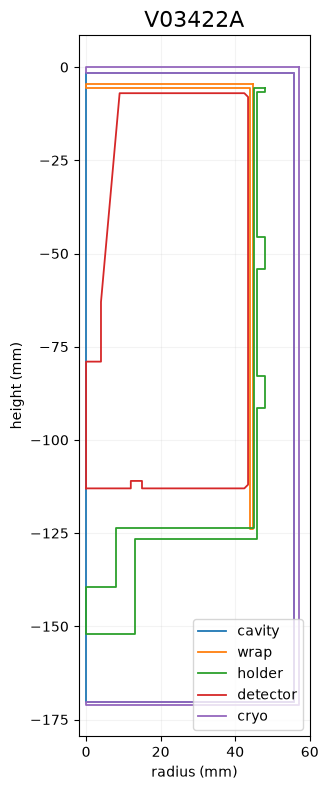

In [7]:

placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(5, 8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [8]:

# simulazione vera e propria

import awkward as ak
import hist
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np

from remage import remage_run
import lh5

isotopes = {
    "Pb212": {
        "Z": 82,
        "A": 212,
        "activity_factor": 1.0,
    },
    "Bi212": {
        "Z": 83,
        "A": 212,
        "activity_factor": 1.0,
    },
    "Tl208": {
        "Z": 81,
        "A": 208,
        "activity_factor": 0.3594,
    },
}

N_sim = 1_000_000
#N_sim = 50000

for name, iso in isotopes.items():

    Z = iso["Z"]
    A = iso["A"]

    macro = [
        "/RMG/Manager/Logging/LogLevel summary",

        "/RMG/Processes/HadronicPhysics Shielding",

        f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",

        "/RMG/Output/NtupleUseVolumeName true",
        "/RMG/Output/NtuplePerDetector false",

        "/run/initialize",

        # Sorgente
        "/RMG/Generator/Confine Volume",
        "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",

        "/RMG/Generator/Select GPS",

        "/gps/particle ion",
        f"/gps/ion {Z} {A}",
        "/gps/energy 0 keV",

        # Simula solo il decadimento di questo isotopo
        f"/process/had/rdm/nucleusLimits {A} {A} {Z} {Z}",

        f"/run/beamOn {N_sim}",
    ]

    output_file = f"{detector}_{measure}_{name}.lh5"
    print("===========")
    print("OUTPUT NAME",output_file)

    try:
        remage_run(
            macros=macro,
            gdml_files=f"{detector}_th_HS2_top_psa_run0001.gdml",
            output=output_file,
            overwrite_output=True
        )

        print(f"✅ {name}: simulazione completata")

    except Exception as e:
        print(f"❌ {name}: {e}")



OUTPUT NAME V03422A_th_HS2_top_psa_Pb212.lh5
  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : GeomVol1002
      issued by : G4PVPlacement::CheckOverlaps()
Overlap with volume already placed !
          Overlap is detected for volume cavity_pv:0 (G4GenericPolycone) with source_holder_pv_1:0 (G4Polycone)
          overlap at local point (-52.1798,-5.97918,41) by 1.47875 mm  (max of 43

[Summary -> CLHEP::HepRandom seed changed to: 944485036 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: .rmg-tmp-94556.V03422A_th_HS2_top_psa_Pb212.hdf5 (for V03422A_th_HS2_top_psa_Pb212.lh5)
[Summary -> Starting run nr. 0. Current local time is 23-09-2026 23:59:56 PDT
[Summary -> Number of events to be processed: 1000000
[Summary -> Processing event nr. 100000 (10%), at 0 days, 0 hours, 0 minutes and 17 seconds
[Summary -> Processing event nr. 200000 (20%), at 0 days, 0 hours, 0 minutes and 34 seconds
[Summary -> Processing event nr. 300000 (30%), at 0 days, 0 hours, 0 minutes and 51 seconds
[Summary -> Processing event nr. 400000 (40%), at 0 days, 0 hours, 1 minutes and 8 seconds
[Summary -> Processing event nr. 500000 (50%), at 0 days, 0 hours, 1 minutes and 24 seconds
[Summary -> Processing event nr. 600000 (60%), at 0 days, 0 hours, 1 minutes and 41 seconds
[Summary -> Processing event nr. 700000 (70%), at 0 days, 0 hour

✅ Pb212: simulazione completata
OUTPUT NAME V03422A_th_HS2_top_psa_Bi212.lh5
  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : GeomVol1002
      issued by : G4PVPlacement::CheckOverlaps()
Overlap with volume already placed !
          Overlap is detected for volume cavity_pv:0 (G4GenericPolycone) with source_holder_pv_1:0 (G4Polycone)
          overlap at local point (-52.1798,-5.979

[Summary -> Opening output file: .rmg-tmp-16086.V03422A_th_HS2_top_psa_Bi212.hdf5 (for V03422A_th_HS2_top_psa_Bi212.lh5)
[Summary -> Starting run nr. 0. Current local time is 24-09-2026 00:03:02 PDT
[Summary -> Number of events to be processed: 1000000
[Summary -> Processing event nr. 100000 (10%), at 0 days, 0 hours, 0 minutes and 14 seconds
[Summary -> Processing event nr. 200000 (20%), at 0 days, 0 hours, 0 minutes and 29 seconds
[Summary -> Processing event nr. 300000 (30%), at 0 days, 0 hours, 0 minutes and 43 seconds
[Summary -> Processing event nr. 400000 (40%), at 0 days, 0 hours, 0 minutes and 58 seconds
[Summary -> Processing event nr. 500000 (50%), at 0 days, 0 hours, 1 minutes and 12 seconds
[Summary -> Processing event nr. 600000 (60%), at 0 days, 0 hours, 1 minutes and 27 seconds
[Summary -> Processing event nr. 700000 (70%), at 0 days, 0 hours, 1 minutes and 41 seconds
[Summary -> Processing event nr. 800000 (80%), at 0 days, 0 hours, 1 minutes and 55 seconds
[Summary ->

✅ Bi212: simulazione completata
OUTPUT NAME V03422A_th_HS2_top_psa_Tl208.lh5
  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : GeomVol1002
      issued by : G4PVPlacement::CheckOverlaps()
Overlap with volume already placed !
          Overlap is detected for volume cavity_pv:0 (G4GenericPolycone) with source_holder_pv_1:0 (G4Polycone)
          overlap at local point (-52.1798,-5.979

[Summary -> Opening output file: .rmg-tmp-70837.V03422A_th_HS2_top_psa_Tl208.hdf5 (for V03422A_th_HS2_top_psa_Tl208.lh5)
[Summary -> Starting run nr. 0. Current local time is 24-09-2026 00:05:41 PDT
[Summary -> Number of events to be processed: 1000000
[Summary -> Processing event nr. 100000 (10%), at 0 days, 0 hours, 1 minutes and 18 seconds
[Summary -> Processing event nr. 200000 (20%), at 0 days, 0 hours, 2 minutes and 37 seconds
[Summary -> Processing event nr. 300000 (30%), at 0 days, 0 hours, 3 minutes and 54 seconds
[Summary -> Processing event nr. 400000 (40%), at 0 days, 0 hours, 5 minutes and 12 seconds
[Summary -> Processing event nr. 500000 (50%), at 0 days, 0 hours, 6 minutes and 29 seconds
[Summary -> Processing event nr. 600000 (60%), at 0 days, 0 hours, 7 minutes and 47 seconds
[Summary -> Processing event nr. 700000 (70%), at 0 days, 0 hours, 9 minutes and 4 seconds
[Summary -> Processing event nr. 800000 (80%), at 0 days, 0 hours, 10 minutes and 23 seconds
[Summary ->

✅ Tl208: simulazione completata


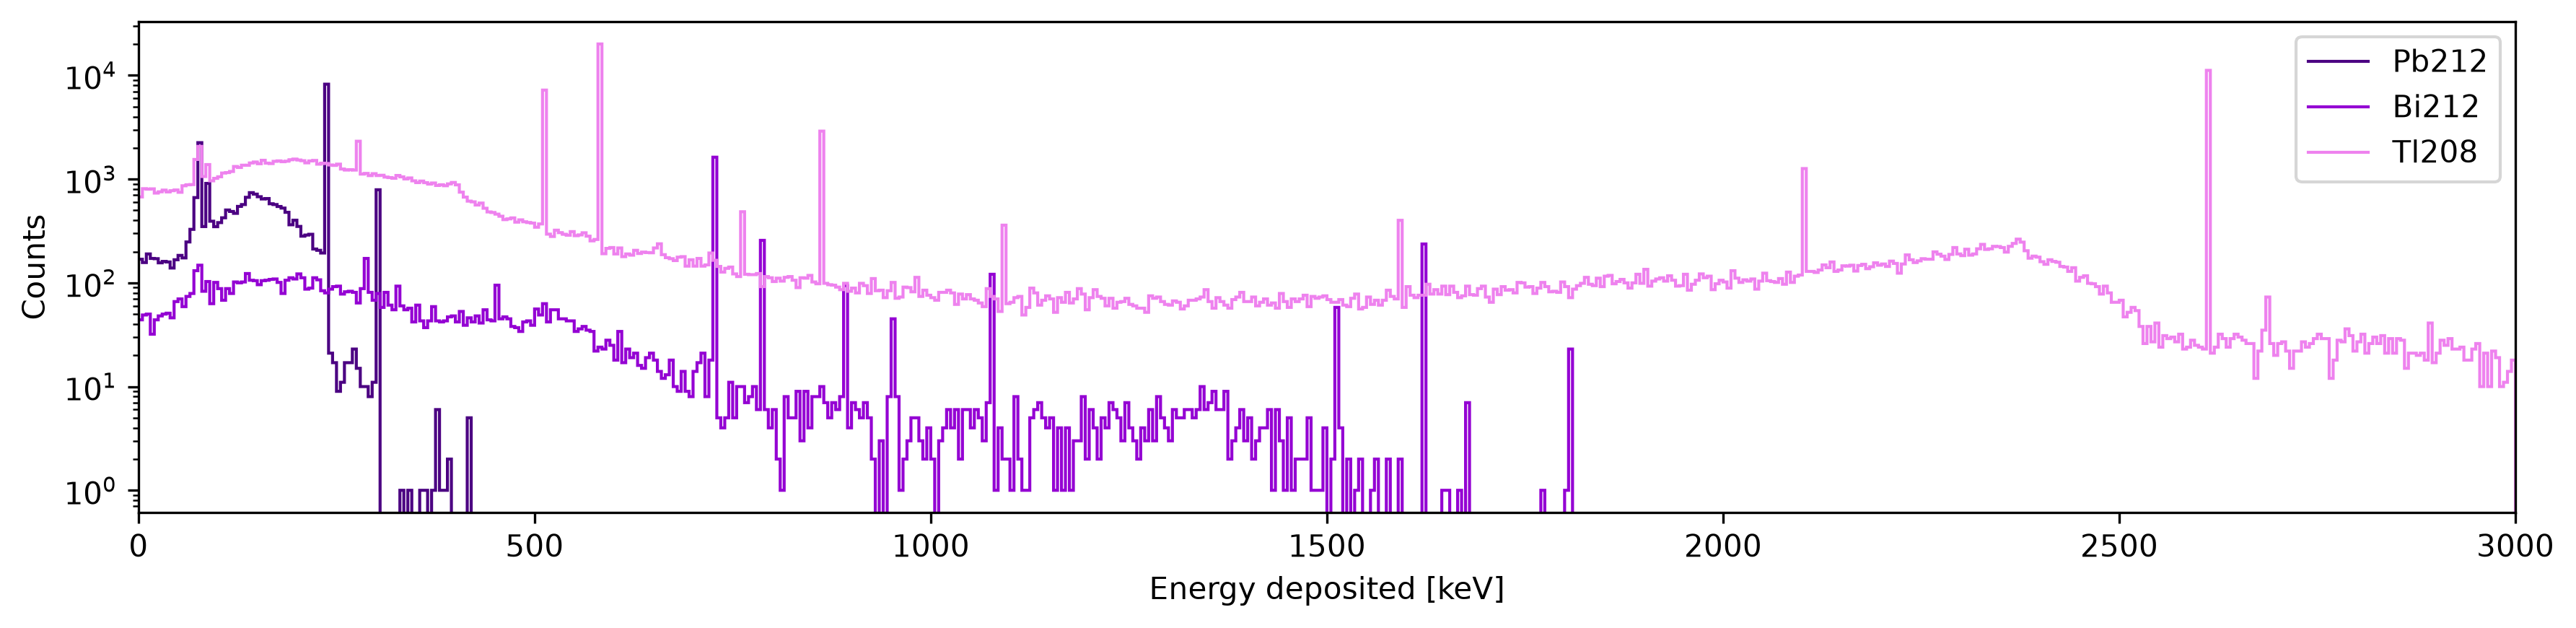

In [9]:

# Stessi bin per tutti
emin = 0
emax = 3000
bins = np.linspace(emin, emax, 601)

# I tre isotopi che vuoi confrontare
isotopes_to_plot = ["Pb212", "Bi212", "Tl208"]

colors = {
    "Pb212": "indigo",
    "Bi212": "darkviolet",
    "Tl208": "violet",
}

plt.figure(figsize=(12, 3), dpi = 300)

has_counts = False

for name in isotopes_to_plot:

    filename = f"{detector}_{measure}_{name}.lh5"

    try:
        data = lh5.read_as(
            "stp/germanium",
            filename,
            "ak"
        )

        # Energia totale depositata nel germanio per evento
        energy = ak.to_numpy(
            ak.sum(data.edep, axis=-1)
        )

        # Tengo solo eventi con deposito di energia
        energy = energy[energy > 0]

        if len(energy) == 0:
            print(f"{name}: non ci sono conteggi nel germanio")
            continue

        counts, bin_edges = np.histogram(
            energy,
            bins=bins
        )

        if np.sum(counts) == 0:
            print(f"{name}: non ci sono conteggi nel germanio")
            continue

        plt.stairs(
            counts,
            bin_edges,
            color=colors[name],
            label=name
        )

        has_counts = True

    except Exception:
        print(f"{name}: non ci sono conteggi nel germanio")


if has_counts:

    plt.xlabel("Energy deposited [keV]")
    plt.ylabel("Counts")
    plt.xlim(emin, emax)
    plt.yscale("log")
    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    plt.close()
    print("Non ci sono conteggi nel germanio")



filename = f"{detector}_{measure}_run0001.lh5"

In [10]:

# post processing

import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids




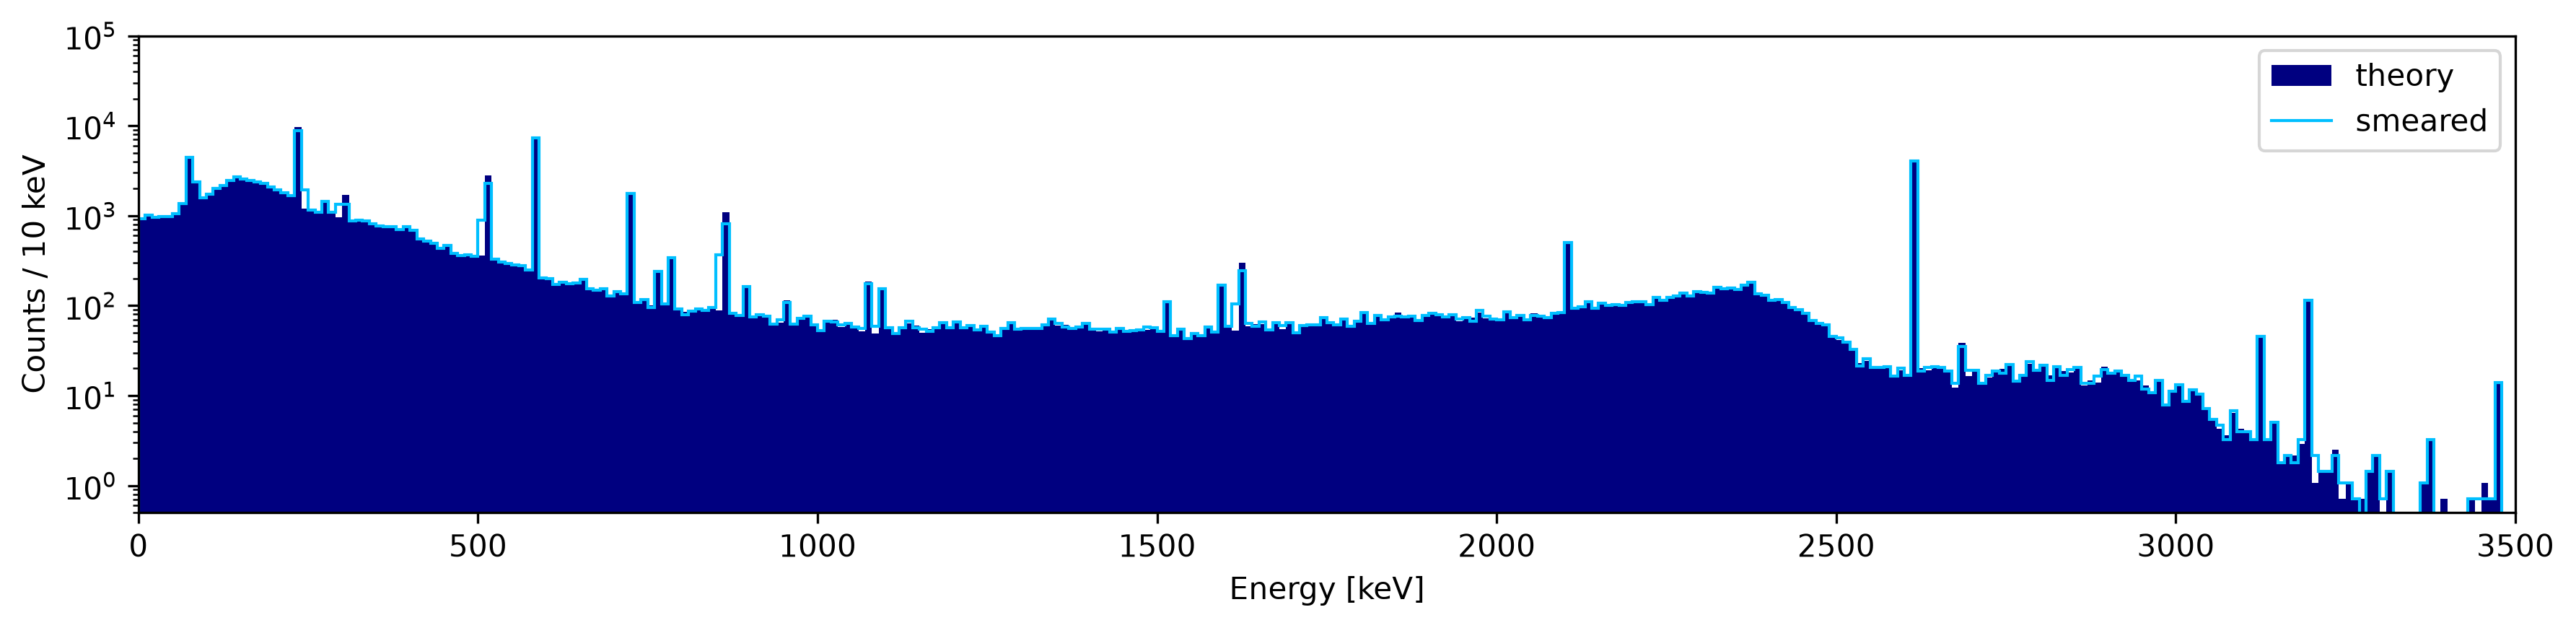

In [11]:


# Isotopi e relativi pesi
BR = {
    "Pb212": 1.0,
    "Bi212": 1.0,
    "Tl208": 0.3594
}

# Impostazioni istogramma
bin_width = 10      # keV
energy_max = 3500   # keV
bin_edges = np.arange(0, energy_max + bin_width, bin_width)

# Istogrammi finali
counts_theory = np.zeros(len(bin_edges) - 1)
counts_smeared = np.zeros(len(bin_edges) - 1)

for name, br in BR.items():

    filename = f"{detector}_{measure}_{name}.lh5"

    try:
        data = lh5.read_as(
            "stp/germanium",
            filename,
            "ak"
        )

        energy = ak.to_numpy(
            ak.sum(data.edep, axis=-1)
        )

        #energy = energy[energy > 0]

        if len(energy) == 0:
            print("⚠️ non ci sono depositi di energia, fai simulazione con più iterazioni")
            continue

    except Exception:
        print("⚠️ non ci sono depositi di energia, fai simulazione con più iterazioni")
        continue

    # Smearing
    energy_smeared = reboost.math.stats.gaussian_sample(
        energy,
        sigma=1
    )
    energy_smeared = ak.to_numpy(energy_smeared)

    counts_iso, _ = np.histogram(
        energy,
        bins=bin_edges
    )

    counts_iso_smeared, _ = np.histogram(
        energy_smeared,
        bins=bin_edges
    )

    counts_theory += br * counts_iso 
    counts_smeared += br * counts_iso_smeared 

counts_MC = counts_smeared
# Plot finale
plt.figure(figsize=(12,3), dpi = 300)

plt.stairs(
    counts_theory,
    bin_edges,
    fill = True,
    color="navy",
    label="theory"
)

plt.stairs(
    counts_smeared,
    bin_edges,
    color="deepskyblue",
    label="smeared"
)

plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bin_width} keV")
plt.ylim(0.5, 1e5)
plt.yscale("log")
#plt.grid(alpha=0.25)
plt.legend()
plt.xlim(0, energy_max)
plt.tight_layout()
plt.show()

# DATA

In [12]:

# data

detector = "V03422A"
run = "r001"
version = "v1.2.1"

measurement_files = sorted(glob.glob(
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/{detector}/c1/*"
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

measurements = [
    os.path.basename(path)
    for path in measurement_files
]

print(measurements)

measure = "th_HS2_top_psa"

file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-*.lh5"
))
file_names_bkg = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/bkg/char_data-{detector}-bkg-r001-*.lh5"
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/V03422A/c1/bkg"
))

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/am_HS1_lat_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/am_HS1_lat_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/am_HS1_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/am_HS1_top_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/am_HS6_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/ba_HS4_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/bkg
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/co_HS5_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03422A/c1/co_HS5_top_hvs
/global/cfs/

In [13]:


len(file_names)

bkg = lh5.read("hit", file_names_bkg)

data = lh5.read("hit", file_names)



df_bkg =  bkg.view_as("pd") 
df = data.view_as("pd")
df.head()

,AoE_Classifier,AoE_Corrected,AoE_Double_Sided_Cut,AoE_High_Side_Cut,AoE_Low_Cut,LQ_Classifier,LQ_Cut,bl_pileup_cut,bl_pileup_cut_classifier,cuspEmax_cal,...,tail_pileup_cut,tail_pileup_cut_classifier,timestamp,tp_0_est,trapEmax_cal,trapEmax_ctc_cal,trapEmax_noctc_cal,zacEmax_cal,zacEmax_ctc_cal,zacEmax_noctc_cal
0,1.408495,1.122891,True,True,True,22.172874,False,True,0.791244,80.209887,...,True,-0.324326,1.711011e+09,29200.0,80.099126,80.099126,80.091796,79.934656,79.934656,79.926483
1,2.068919,1.183554,True,True,True,23.962933,False,True,-0.292304,76.672751,...,True,-0.250973,1.711011e+09,29296.0,76.649342,76.649342,76.643143,76.723297,76.723297,76.716364
2,-2.905885,0.920554,False,True,False,2.529213,True,True,-1.034530,193.616044,...,True,-1.006162,1.711011e+09,29040.0,193.622353,193.622353,193.601092,193.517098,193.517098,193.493371
3,-6.372116,0.907014,False,True,False,12.448535,False,True,2.434927,357.525368,...,True,0.031170,1.711011e+09,28800.0,357.635132,357.635132,357.585759,357.483848,357.483848,357.428755
4,-34.201617,0.704445,False,True,False,6.749543,False,True,0.861058,645.839235,...,True,2.292582,1.711011e+09,28800.0,645.815517,645.815517,645.726191,645.771942,645.771942,645.672246


In [14]:
# Fattore di normalizzazione del background
alpha = time_measurement / time_bkg

print("\nNormalizzazione")
print(f"Tempo misura: {time_measurement:.2f} s")
print(f"Tempo background: {time_bkg:.2f} s")
print(f"Alpha: {alpha:.6f}")


Normalizzazione
Tempo misura: 18000.00 s
Tempo background: 61200.00 s
Alpha: 0.294118


In [15]:

E_noQC = df["cuspEmax_ctc_cal"]

mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)

mask_highPSD = (
    mask_clean
    & df["AoE_High_Side_Cut"]
)

mask_PSD = (
    mask_clean
    & df["AoE_Double_Sided_Cut"]
)

mask_noPSD = (
    mask_clean
    & ~df["AoE_Double_Sided_Cut"]
)


# Background: stesse selezioni applicate ai dati
mask_bkg = (
    ~df_bkg["is_discharge"]
    & df_bkg["is_positive_polarity_candidate"]
)

mask_PSD_bkg = (
    mask_bkg
    & df_bkg["AoE_Double_Sided_Cut"]
)


E = df.loc[
    mask_clean,
    "cuspEmax_ctc_cal"
]

E_bkg = df_bkg.loc[
    mask_bkg,
    "cuspEmax_ctc_cal"
]

E_PSD = df.loc[
    mask_PSD,
    "cuspEmax_ctc_cal"
]

E_PSD_bkg = df_bkg.loc[
    mask_PSD_bkg,
    "cuspEmax_ctc_cal"
]

In [16]:

emin = 0
emax = 3500
bins = 350

# Bordi comuni
bin_edges = np.linspace(
    emin,
    emax,
    bins + 1
)


# --------------------------------------------------
# DATI DOPO QC
# --------------------------------------------------

counts_data, _ = np.histogram(
    E,
    bins=bin_edges
)


# --------------------------------------------------
# BACKGROUND DOPO QC
# --------------------------------------------------

counts_bkg, _ = np.histogram(
    E_bkg,
    bins=bin_edges
)

counts_bkg_scaled = (
    alpha * counts_bkg
)

counts_net = (
    counts_data
    - counts_bkg_scaled
)


# --------------------------------------------------
# DATI DOPO PSD
# --------------------------------------------------

counts_PSD, _ = np.histogram(
    E_PSD,
    bins=bin_edges
)


# --------------------------------------------------
# BACKGROUND DOPO PSD
# --------------------------------------------------

counts_PSD_bkg, _ = np.histogram(
    E_PSD_bkg,
    bins=bin_edges
)

counts_PSD_bkg_scaled = (
    alpha * counts_PSD_bkg
)

counts_PSD_net = (
    counts_PSD
    - counts_PSD_bkg_scaled
)


# --------------------------------------------------
# RIEPILOGO
# --------------------------------------------------

print("Conteggi dati:", counts_data.sum())
print("Conteggi background:", counts_bkg.sum())
print(
    "Conteggi background normalizzati:",
    counts_bkg_scaled.sum()
)
print(
    "Conteggi netti:",
    counts_net.sum()
)

print("\nConteggi dati dopo PSD:", counts_PSD.sum())
print(
    "Conteggi background dopo PSD:",
    counts_PSD_bkg.sum()
)
print(
    "Conteggi background normalizzati dopo PSD:",
    counts_PSD_bkg_scaled.sum()
)
print(
    "Conteggi netti dopo PSD:",
    counts_PSD_net.sum()
)


Conteggi dati: 4574429
Conteggi background: 833562
Conteggi background normalizzati: 245165.29411764708
Conteggi netti: 4329263.705882353

Conteggi dati dopo PSD: 2073676
Conteggi background dopo PSD: 453012
Conteggi background normalizzati dopo PSD: 133238.82352941178
Conteggi netti dopo PSD: 1940437.1764705884


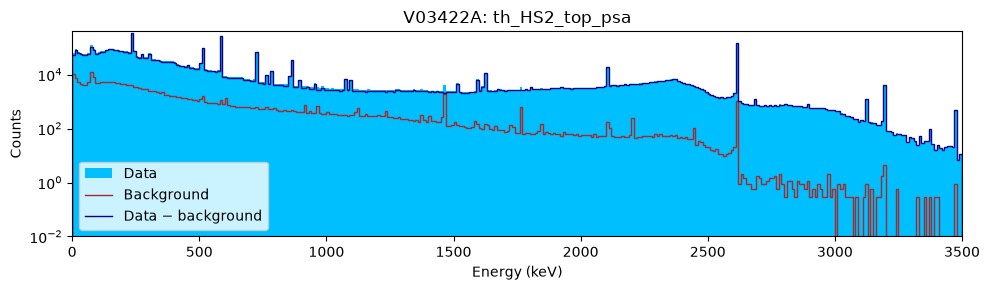

In [17]:

# Bordi comuni a tutti gli istogrammi
bin_edges = np.linspace(
    emin,
    emax,
    bins + 1
)

# Plot
plt.figure(figsize=(10, 3))

# Dati dopo QC, senza sottrazione
plt.stairs(
    counts_data,
    bin_edges,
    fill=True,
    color="deepskyblue",
    label="Data"
)
'''
# Dati dopo PSD, senza sottrazione
plt.stairs(
    counts_PSD,
    bin_edges,
    fill = True,
    color="orange",
    #linewidth=1.2,
    label="Data after A/E"
)'''

plt.stairs(counts_bkg_scaled,
          bin_edges,
          color = 'brown',
          label = 'Background')

# Dati dopo QC, con background sottratto
plt.stairs(
    counts_net,
    bin_edges,
    color="navy",
    #linewidth=1.2,
    label="Data − background"
)
'''
# Dati dopo PSD, con background sottratto
plt.stairs(
    counts_PSD_net,
    bin_edges,
    color="red",
    #linewidth=1.2,
    label="After A/E − background"
)'''

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlim(emin, emax)
#plt.xlim(1100, 1500)
plt.yscale('log')
plt.ylim(1e-2, 4e5)

plt.title(f"{detector}: {measure}")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

plt.tight_layout()
plt.show()

# CONFRONTO CON I DATI

In [18]:
from scipy.stats import truncnorm

In [19]:
def sample_truncated_gaussian(mu, sigma, size=1):
    a = (0 - mu) / sigma
    b = np.inf

    return truncnorm.rvs(
        a,
        b,
        loc=mu,
        scale=sigma,
        size=size
    )

In [68]:
activity_mean = 87e3   # Bq
activity_sigma = 4e3   # esempio


activities = sample_truncated_gaussian(
    activity_mean,
    activity_sigma,
    size=len(counts_MC)
)

N_real = activities * time_measurement

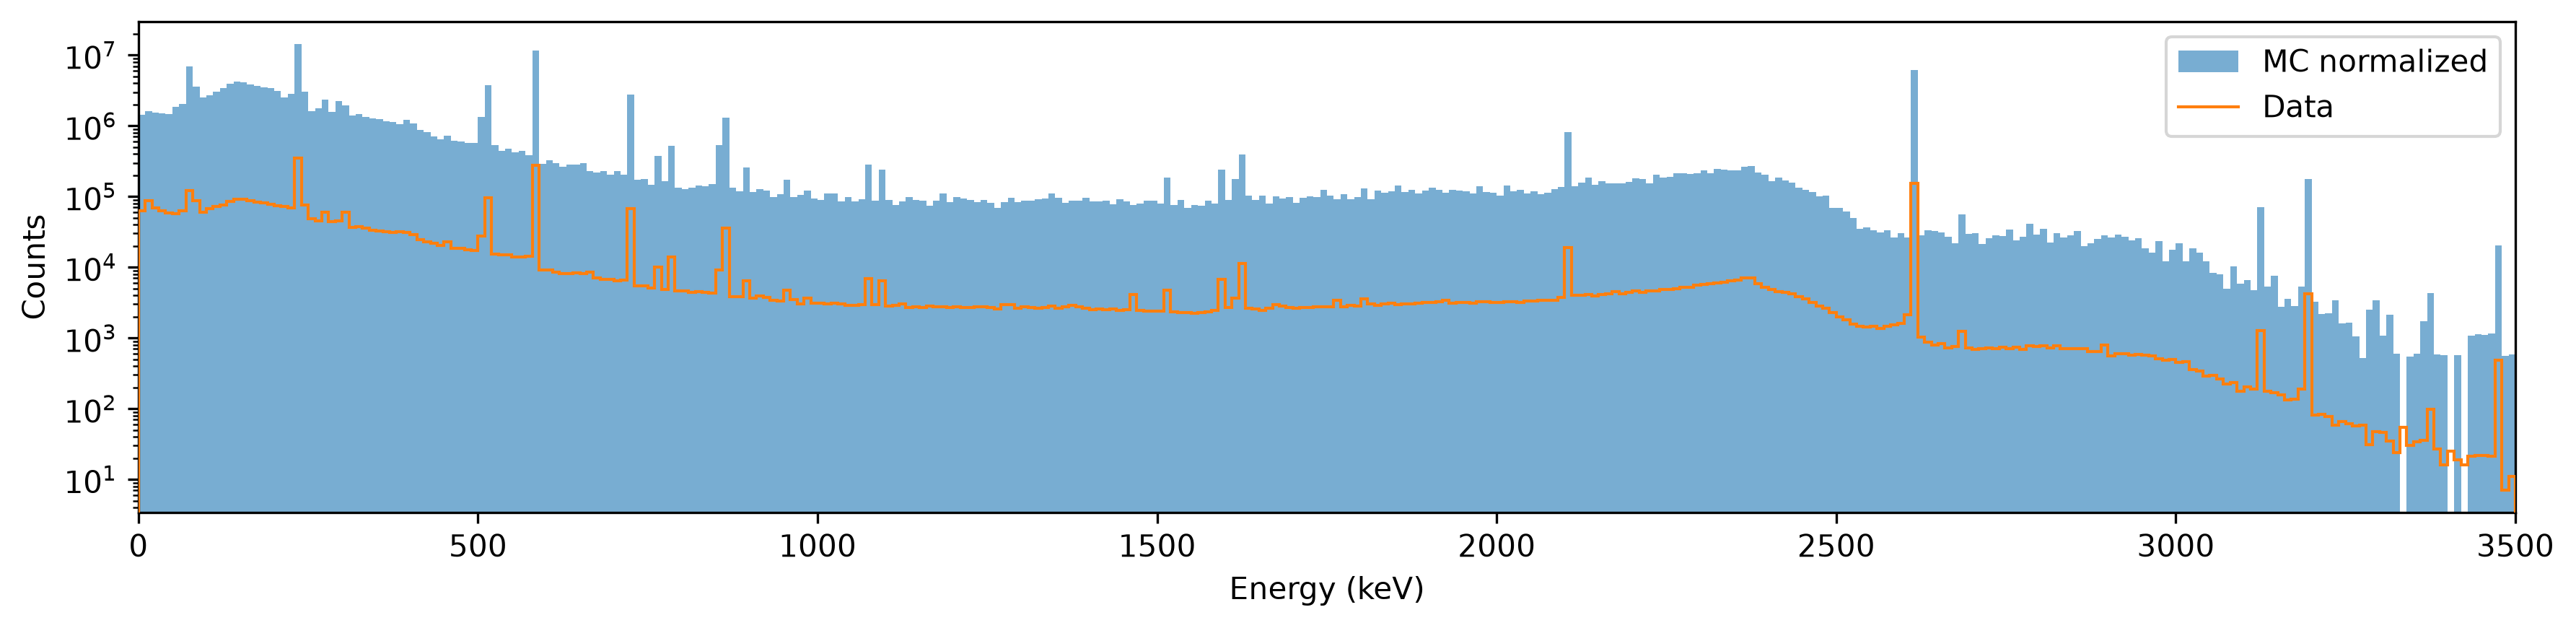

In [75]:

plt.figure(figsize=(12, 3), dpi = 300)
#plt.hist(energy_smeared, bins =bin_edges[:-1], weights = np.full(len(energy_smeared), weight),  color = 'navy', label = 'theory')

plt.stairs(
    counts_MC * N_real / N_sim,
    bin_edges,
    #weights=weights_MC,
    fill = True,
    #color="green",
    alpha = 0.6,
    label="MC normalized"
)



plt.stairs(
    counts_data,
    bin_edges,
    #fill = True,
    #color="deepskyblue",
    label="Data",
    zorder = 10
)


plt.xlim(emin, emax)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

#ùplt.vlines(2614, 1, 1e5, color = 'red')

plt.tight_layout()
plt.show()




In [24]:
name

'Tl208'